In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [4]:
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target 

print(f"Orijinal Veri Seti Boyutu: {X.shape} \n")

Orijinal Veri Seti Boyutu: (178, 13) 



In [5]:
# ÖLÇEKLENDİRME 
# PCA mesafeler ve varyans üzerinden çalıştığı için veriyi aynı ölçeğe getirmek zorunludur.
scaler = StandardScaler()
X_olcekli = scaler.fit_transform(X)

# PCA MODELİNİ KURMA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_olcekli)

print(f"PCA Sonrası Yeni Veri Seti Boyutu: {X_pca.shape} \n")

pca_df = pd.DataFrame(data=X_pca, columns=['Temel Bileşen 1 (PC1)', 'Temel Bileşen 2 (PC2)'])
pca_df['Sınıf'] = y

PCA Sonrası Yeni Veri Seti Boyutu: (178, 2) 



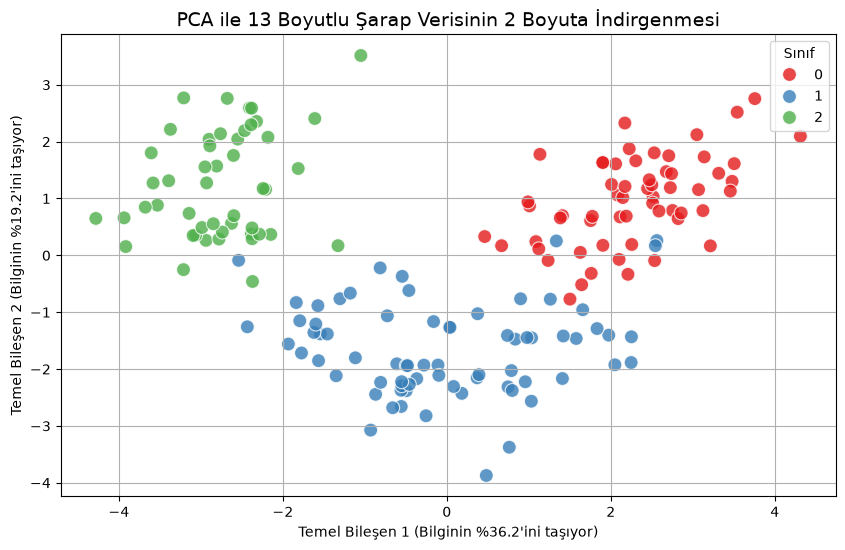

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Temel Bileşen 1 (PC1)', 
    y='Temel Bileşen 2 (PC2)', 
    hue='Sınıf', 
    data=pca_df, 
    palette='Set1', 
    s=100, 
    alpha=0.8
)

plt.title('PCA ile 13 Boyutlu Şarap Verisinin 2 Boyuta İndirgenmesi', fontsize=14)
plt.xlabel(f'Temel Bileşen 1 (Bilginin %{pca.explained_variance_ratio_[0]*100:.1f}\'ini taşıyor)')
plt.ylabel(f'Temel Bileşen 2 (Bilginin %{pca.explained_variance_ratio_[1]*100:.1f}\'ini taşıyor)')
plt.grid(True)
plt.show()